# Домашнее задание 2

## Porto Seguro Safe Driver Prediction

В этой работе мы прогнозируем вероятность страхового случая в следующем году.

[Страница соревнования](https://www.kaggle.com/c/porto-seguro-safe-driver-prediction)

## Метрика

В соревновании мы используем Normalized Gini. С помощью этой метрики мы оцениваем качество ранжирования объектов по вероятности страхового случая. Для бинарной задачи связываем ее с ROC-AUC формулой `Gini = 2 * ROC-AUC - 1`. Поэтому во всех экспериментах сравниваем модели по одной метрике.

Положительный класс встречаем редко. Из-за этого не используем accuracy для сравнения моделей.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path
import time
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from scipy import sparse

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
CV_SAMPLE_SIZE = 120_000
DATA_DIR = Path(".")
sns.set_theme(style="whitegrid", palette="deep")

## 1. Загрузка данных

Значением `-1` в этом наборе обозначаем пропуск. На первом этапе оставляем его без изменений, чтобы отдельно оценить масштаб проблемы.

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_path = DATA_DIR / "sample_submission.csv"
if sample_path.exists():
    sample_submission = pd.read_csv(sample_path)
else:
    sample_submission = pd.DataFrame({"id": test["id"], "target": 0.0})

overview = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "columns": [train.shape[1], test.shape[1]],
        "duplicates": [train.duplicated().sum(), test.duplicated().sum()],
    },
    index=["train", "test"],
)
display(overview)
display(train.head(3))

original_features = [
    column for column in train.columns if column not in ["id", "target"]
]
categorical_features = [
    column for column in original_features if column.endswith("_cat")
]
binary_features = [column for column in original_features if column.endswith("_bin")]
print("Число исходных признаков", len(original_features))
print("Категориальных признаков", len(categorical_features))
print("Бинарных признаков", len(binary_features))

         rows  columns  duplicates
train  595212       59           0
test   892816       58           0

   id  target  ps_ind_01  ps_ind_02_cat  ps_ind_03  ps_ind_04_cat  \
0   7       0          2              2          5              1   
1   9       0          1              1          7              0   
2  13       0          5              4          9              1   

   ps_ind_05_cat  ps_ind_06_bin  ps_ind_07_bin  ps_ind_08_bin  ...  \
0              0              0              1              0  ...   
1              0              0              0              1  ...   
2              0              0              0              1  ...   

   ps_calc_11  ps_calc_12  ps_calc_13  ps_calc_14  ps_calc_15_bin  \
0           9           1           5           8               0   
1           3           1           1           9               0   
2           4           2           7           7               0   

   ps_calc_16_bin  ps_calc_17_bin  ps_calc_18_bin  ps_calc_19_bin  \
0               1               1               0               0   
1               1          

Число исходных признаков 57
Категориальных признаков 14
Бинарных признаков 17


## 2. EDA

Сначала проверяем баланс цели и доли пропусков. Затем смотрим на простые линейные связи. Поскольку названия признаков анонимизированы, формулируем выводы по структуре данных и результатам кросс-валидации.

         count  share_percent
target                       
0       573518          96.36
1        21694           3.64

               missing_percent
ps_car_03_cat            69.09
ps_car_05_cat            44.78
ps_reg_03                18.11
ps_car_14                 7.16
ps_car_07_cat             1.93
ps_ind_05_cat             0.98
ps_car_09_cat             0.10
ps_ind_02_cat             0.04
ps_car_01_cat             0.02
ps_ind_04_cat             0.01

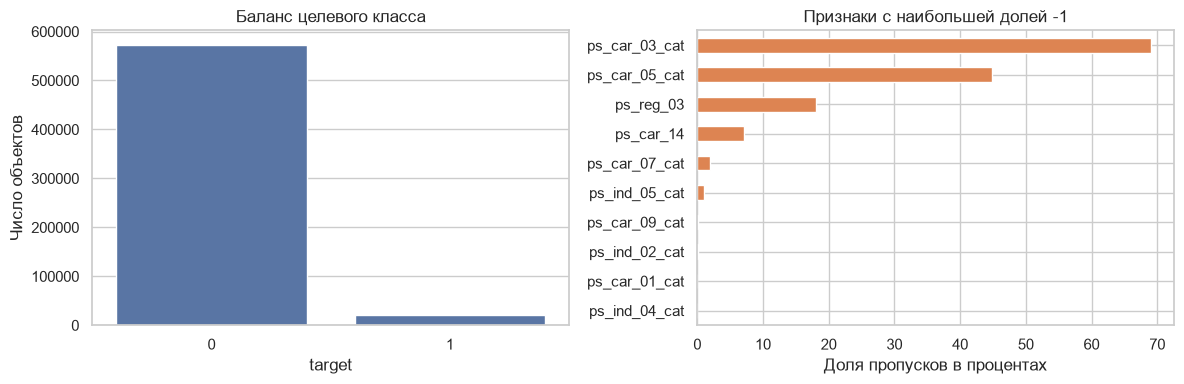

In [3]:
target_table = train["target"].value_counts().sort_index().to_frame("count")
target_table["share"] = train["target"].value_counts(normalize=True).sort_index()
target_table["share_percent"] = (target_table.pop("share") * 100).round(2)
display(target_table)

missing_share = (train[original_features] == -1).mean().sort_values(ascending=False)
display((missing_share.head(10) * 100).round(2).to_frame("missing_percent"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train, x="target", ax=axes[0], color="#4C72B0")
axes[0].set_title("Баланс целевого класса")
axes[0].set_xlabel("target")
axes[0].set_ylabel("Число объектов")

(missing_share.head(10) * 100).sort_values().plot(
    kind="barh", ax=axes[1], color="#DD8452"
)
axes[1].set_title("Признаки с наибольшей долей -1")
axes[1].set_xlabel("Доля пропусков в процентах")
plt.tight_layout()
plt.show()

**Промежуточный вывод**

В train мы видим 595 212 строк и 58 признаков без учета `id` и цели. Полных дубликатов не находим. Положительный класс занимает только 3.64 процента данных. Самые большие доли пропусков наблюдаем у `ps_car_03_cat`, `ps_car_05_cat` и `ps_reg_03`. При удалении всех неполных строк мы потеряем большую часть данных, поэтому дальше заполняем пропуски медианой внутри каждого обучающего фолда.

               correlation
ps_car_07_cat      -0.0364
ps_ind_06_bin      -0.0340
ps_car_02_cat      -0.0315
ps_ind_05_cat       0.0292
ps_reg_03           0.0309
ps_car_03_cat       0.0324
ps_car_04_cat       0.0329
ps_ind_07_bin       0.0342
ps_reg_02           0.0348
ps_ind_17_bin       0.0371
ps_car_12           0.0388
ps_car_13           0.0539

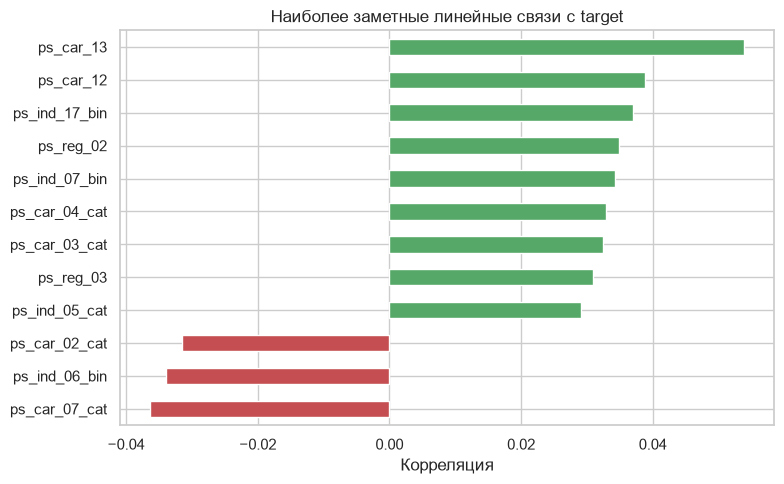

        ps_car_13  ps_car_12  ps_reg_02
target                                 
0          0.8109     0.3795     0.4364
1          0.8755     0.3916     0.5115

In [4]:
correlations = train[original_features].corrwith(train["target"]).sort_values()
strongest = correlations.abs().sort_values(ascending=False).head(12).index
correlation_table = correlations.loc[strongest].sort_values()
display(correlation_table.round(4).to_frame("correlation"))

plt.figure(figsize=(8, 5))
colors = np.where(correlation_table > 0, "#55A868", "#C44E52")
correlation_table.plot(kind="barh", color=colors)
plt.title("Наиболее заметные линейные связи с target")
plt.xlabel("Корреляция")
plt.tight_layout()
plt.show()

group_comparison = train.groupby("target")[
    ["ps_car_13", "ps_car_12", "ps_reg_02"]
].mean()
display(group_comparison.round(4))

**Промежуточный вывод**

Мы видим слабые отдельные линейные связи с целью. Наибольшую абсолютную корреляцию около `0.054` получаем у `ps_car_13`. Для клиентов со страховым случаем наблюдаем более высокое среднее значение этого признака. Поэтому не ограничиваемся одной линейной моделью и проверяем нелинейные алгоритмы.

## 3. Feature engineering

Создаем пять простых признаков.

1. С помощью `missing_count` считаем число неизвестных значений в строке
2. С помощью `ind_bin_sum` суммируем бинарные признаки группы `ind`
3. С помощью `calc_bin_sum` сжимаем бинарные признаки группы `calc`
4. С помощью `car_13_sq` добавляем нелинейную версию наиболее связанного с целью признака
5. С помощью `car_12_x_13` добавляем простое взаимодействие двух автомобильных признаков

После создания новых полей заменяем `-1` на `NaN`. Заполняем пропуски только внутри Pipeline.

In [5]:
def make_features(frame, add_features=True, drop_calc=False):
    x = frame[original_features].copy()

    if add_features:
        ind_bin = [
            column
            for column in original_features
            if column.startswith("ps_ind") and column.endswith("_bin")
        ]
        calc_bin = [
            column
            for column in original_features
            if column.startswith("ps_calc") and column.endswith("_bin")
        ]
        x["missing_count"] = (x == -1).sum(axis=1).astype("int8")
        x["ind_bin_sum"] = x[ind_bin].sum(axis=1).astype("int8")
        x["calc_bin_sum"] = x[calc_bin].sum(axis=1).astype("int8")
        x["car_13_sq"] = x["ps_car_13"] ** 2
        x["car_12_x_13"] = x["ps_car_12"] * x["ps_car_13"]

    if drop_calc:
        calc_columns = [
            column for column in original_features if column.startswith("ps_calc_")
        ]
        x = x.drop(columns=calc_columns)

    return x.replace(-1, np.nan).astype("float32")


def normalized_gini(y_true, probability):
    return 2 * roc_auc_score(y_true, probability) - 1


cv_data = train.sample(n=CV_SAMPLE_SIZE, random_state=RANDOM_STATE)
y_cv = cv_data["target"].astype("int8")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

hist_baseline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=180,
                learning_rate=0.06,
                max_leaf_nodes=31,
                min_samples_leaf=40,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

## 4. Итерации с признаками

Для быстрых экспериментов используем фиксированную стратифицированную подвыборку из 120 000 строк. Финальные модели обучаем на полном train. Так мы сохраняем честное сравнение и заметно сокращаем время выполнения. Это важно, поскольку мы работаем на не самом мощном Mac и не используем внешний сервер.

In [6]:
feature_variants = {
    "Исходные признаки": make_features(cv_data, add_features=False, drop_calc=False),
    "Пять новых признаков": make_features(cv_data, add_features=True, drop_calc=False),
    "Новые признаки без ps_calc": make_features(
        cv_data, add_features=True, drop_calc=True
    ),
}

feature_rows = []
for name, x_variant in feature_variants.items():
    auc_scores = cross_val_score(
        hist_baseline, x_variant, y_cv, cv=cv, scoring="roc_auc", n_jobs=-1
    )
    gini_scores = 2 * auc_scores - 1
    feature_rows.append(
        {
            "variant": name,
            "mean_gini": gini_scores.mean(),
            "std_gini": gini_scores.std(),
            "folds": np.round(gini_scores, 4),
        }
    )

feature_results = (
    pd.DataFrame(feature_rows)
    .set_index("variant")
    .sort_values("mean_gini", ascending=False)
)
display(feature_results)

                            mean_gini  std_gini                     folds
variant                                                                  
Исходные признаки            0.247193  0.004831  [0.2467, 0.2415, 0.2533]
Пять новых признаков         0.247048  0.000734   [0.2478, 0.246, 0.2474]
Новые признаки без ps_calc   0.246248  0.004082  [0.2496, 0.2405, 0.2486]

**Вывод по итерациям**

На исходных признаках получаем средний Gini около `0.247`. После добавления пяти признаков почти не меняем среднее качество, но делаем результаты фолдов ровнее. При удалении исходных полей `ps_calc` также сохраняем качество и уменьшаем число столбцов. Поэтому дальше оставляем новые признаки и убираем исходную группу `ps_calc`. Часть ее бинарной информации сохраняем в `calc_bin_sum`.

## 5. Сравнение моделей

Проверяем четыре базовых алгоритма на одинаковых фолдах. Логистическую регрессию используем как линейный baseline. С помощью одного дерева и случайного леса оцениваем возможности обычных древесных моделей. С помощью гистограммного градиентного бустинга последовательно исправляем ошибки предыдущих деревьев.

                             mean_gini  std_gini  seconds
model                                                    
Histogram gradient boosting     0.2462    0.0041   3.3217
Logistic regression             0.2396    0.0037   1.8163
Random forest                   0.1954    0.0053  19.0744
Decision tree                   0.1659    0.0070   2.2008

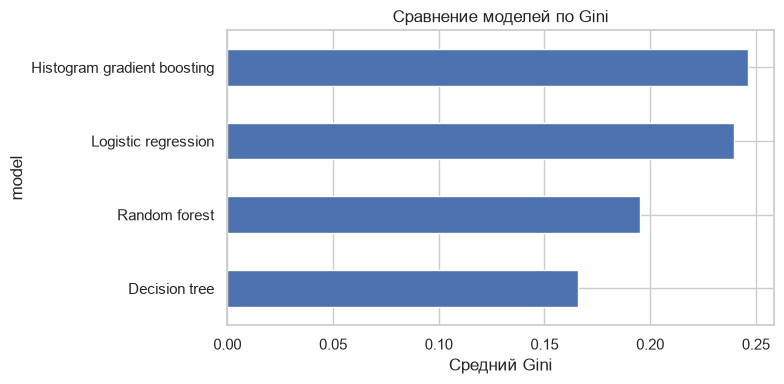

In [7]:
x_cv = make_features(cv_data, add_features=True, drop_calc=True)

linear_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=500, C=0.2, class_weight="balanced", random_state=RANDOM_STATE
            ),
        ),
    ]
)

models = {
    "Logistic regression": linear_model,
    "Decision tree": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=7,
                    min_samples_leaf=100,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random forest": Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=14,
                    min_samples_leaf=30,
                    max_features=0.5,
                    class_weight="balanced_subsample",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Histogram gradient boosting": hist_baseline,
}

model_rows = []
for name, model in models.items():
    started = time.time()
    auc_scores = cross_val_score(model, x_cv, y_cv, cv=cv, scoring="roc_auc", n_jobs=-1)
    gini_scores = 2 * auc_scores - 1
    model_rows.append(
        {
            "model": name,
            "mean_gini": gini_scores.mean(),
            "std_gini": gini_scores.std(),
            "seconds": time.time() - started,
        }
    )

model_results = (
    pd.DataFrame(model_rows)
    .set_index("model")
    .sort_values("mean_gini", ascending=False)
)
display(model_results.round(4))

model_results["mean_gini"].sort_values().plot(
    kind="barh", figsize=(8, 4), color="#4C72B0"
)
plt.title("Сравнение моделей по Gini")
plt.xlabel("Средний Gini")
plt.tight_layout()
plt.show()

**Вывод по моделям**

Лучший результат получаем у гистограммного градиентного бустинга с Gini около `0.246`. Для логистической регрессии получаем около `0.240`. Одно дерево и случайный лес работают заметно слабее. Мы видим, что простым увеличением числа независимых деревьев не решаем задачу, а последовательным исправлением ошибок получаем более высокое качество. Поэтому дальше не используем отдельные древесные модели.

## 6. Подбор гиперпараметров

Для лучшей модели подбираем размер дерева и силу регуляризации. Используем небольшую и понятную сетку. Проверяем, сможет ли более крупное дерево находить сложные связи без сильного переобучения.

In [8]:
search_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=180,
                learning_rate=0.06,
                min_samples_leaf=40,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

parameter_grid = {
    "model__max_leaf_nodes": [15, 31, 63],
    "model__l2_regularization": [1.0, 4.0],
}

grid_search = GridSearchCV(
    search_model,
    parameter_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
grid_search.fit(x_cv, y_cv)

tuning_results = pd.DataFrame(grid_search.cv_results_)
tuning_results["mean_gini"] = 2 * tuning_results["mean_test_score"] - 1
tuning_view = tuning_results[
    [
        "param_model__max_leaf_nodes",
        "param_model__l2_regularization",
        "mean_gini",
        "std_test_score",
    ]
].sort_values("mean_gini", ascending=False)
display(tuning_view.round(5))
print("Лучшие параметры", grid_search.best_params_)
print("Лучший средний Gini", round(2 * grid_search.best_score_ - 1, 5))

   param_model__max_leaf_nodes  param_model__l2_regularization  mean_gini  \
0                           15                             1.0    0.25462   
3                           15                             4.0    0.25391   
1                           31                             1.0    0.24625   
4                           31                             4.0    0.24323   
2                           63                             1.0    0.23685   
5                           63                             4.0    0.23493   

   std_test_score  
0         0.00116  
3         0.00143  
1         0.00204  
4         0.00322  
2         0.00063  
5         0.00282  

Лучшие параметры {'model__l2_regularization': 1.0, 'model__max_leaf_nodes': 15}
Лучший средний Gini 0.25462


**Вывод по подбору**

Лучший результат получаем с 15 листьями и регуляризацией `1.0`. Средний Gini увеличиваем примерно с `0.246` до `0.255`. Мы видим, что меньшее дерево работает устойчивее, поэтому не усложняем модель.

## 7. Ансамбль

Линейная модель и бустинг находят разные зависимости. Объединяем их out of fold прогнозы с помощью простого weighted blending и проверяем несколько весов.

In [9]:
tuned_hist = clone(grid_search.best_estimator_)
oof_linear = np.zeros(len(x_cv), dtype="float32")
oof_hist = np.zeros(len(x_cv), dtype="float32")

for train_index, valid_index in cv.split(x_cv, y_cv):
    x_fold_train = x_cv.iloc[train_index]
    x_fold_valid = x_cv.iloc[valid_index]
    y_fold_train = y_cv.iloc[train_index]

    fold_linear = clone(linear_model)
    fold_hist = clone(tuned_hist)
    fold_linear.fit(x_fold_train, y_fold_train)
    fold_hist.fit(x_fold_train, y_fold_train)
    oof_linear[valid_index] = fold_linear.predict_proba(x_fold_valid)[:, 1]
    oof_hist[valid_index] = fold_hist.predict_proba(x_fold_valid)[:, 1]

blend_rows = []
for hist_weight in [0.7, 0.8, 0.9, 1.0]:
    blend_probability = hist_weight * oof_hist + (1 - hist_weight) * oof_linear
    blend_rows.append(
        {
            "hist_weight": hist_weight,
            "linear_weight": 1 - hist_weight,
            "gini": normalized_gini(y_cv, blend_probability),
        }
    )

blend_results = pd.DataFrame(blend_rows).sort_values("gini", ascending=False)
display(blend_results.round(5))
best_hist_weight = float(blend_results.iloc[0]["hist_weight"])
best_linear_weight = 1 - best_hist_weight
print("Вес бустинга", best_hist_weight)
print("Вес логистической регрессии", best_linear_weight)

   hist_weight  linear_weight     gini
2          0.9            0.1  0.25748
3          1.0            0.0  0.25431
1          0.8            0.2  0.25423
0          0.7            0.3  0.25102

Вес бустинга 0.9
Вес логистической регрессии 0.09999999999999998


**Вывод по ансамблю**

Для лучшего бленда получаем около `0.257` Gini при весе бустинга `0.9` и весе логистической регрессии `0.1`. Получаем небольшой, но устойчивый прирост на out of fold прогнозах без использования test. Поэтому выбираем этот ансамбль для первого финального обучения.

## 8. Обучение на всех данных и submission

После завершения экспериментов обучаем обе модели на полном train.

Сохраняем прогноз в формате образца Kaggle.

In [10]:
x_full = make_features(train, add_features=True, drop_calc=True)
x_test = make_features(test, add_features=True, drop_calc=True)
y_full = train["target"].astype("int8")

final_hist = clone(tuned_hist)
final_linear = clone(linear_model)
final_hist.fit(x_full, y_full)
final_linear.fit(x_full, y_full)

test_hist = final_hist.predict_proba(x_test)[:, 1]
test_linear = final_linear.predict_proba(x_test)[:, 1]
test_probability = best_hist_weight * test_hist + best_linear_weight * test_linear

submission = sample_submission.copy()
submission["target"] = test_probability
submission_path = DATA_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

assert submission.columns.tolist() == ["id", "target"]
assert len(submission) == len(test)
assert submission["target"].between(0, 1).all()
assert submission["id"].equals(test["id"])

display(submission.head())
print("Строк в submission", len(submission))
print("Файл сохранен", submission_path.resolve())

## Итог первого этапа

Начинаем с Gini около `0.247` у бустинга на исходных данных. Добавляем пять признаков и компактно сохраняем часть информации после удаления исходной группы `ps_calc`. Сравниваем четыре модели и видим преимущество градиентного бустинга. После подбора меньшего дерева увеличиваем Gini примерно до `0.255`. С помощью weighted blending получаем около `0.257`.

Лучший эффект получаем от ограничения сложности бустинга и небольшого веса линейной модели. Самые слабые результаты получаем у одиночного дерева и случайного леса. При использовании слишком крупных деревьев в бустинге также ухудшаем качество.

## 9. Результат первого submission

![Результат первого submission](pics/kaggle_score_0_27610.png)

- Score `0.27610`
- Public score `0.27003`

## 10. Второй submission с one-hot encoding

Во второй попытке меняем только представление категориальных признаков.

Сохраняем HistGradientBoosting и логистическую регрессию с весами `0.9` и `0.1`. Значения `cat` переводим в one-hot представление.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

x_second_train = make_features(train, add_features=True, drop_calc=True)
x_second_test = make_features(test, add_features=True, drop_calc=True)
y_second = train["target"].astype("int8").to_numpy()

second_cat_columns = [
    column for column in x_second_train.columns if column.endswith("_cat")
]
second_num_columns = [
    column for column in x_second_train.columns if column not in second_cat_columns
]

second_preprocessor = ColumnTransformer(
    [
        ("num", SimpleImputer(strategy="median"), second_num_columns),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                            dtype=np.float32,
                        ),
                    ),
                ]
            ),
            second_cat_columns,
        ),
    ],
    sparse_threshold=0.0,
)

x_second_train_encoded = second_preprocessor.fit_transform(x_second_train).astype(
    "float32"
)
x_second_test_encoded = second_preprocessor.transform(x_second_test).astype("float32")

second_hist_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=180,
                learning_rate=0.06,
                max_leaf_nodes=15,
                min_samples_leaf=40,
                l2_regularization=1.0,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
second_linear_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=500, C=0.2, class_weight="balanced", random_state=RANDOM_STATE
            ),
        ),
    ]
)

second_train_index, second_valid_index = train_test_split(
    np.arange(len(y_second)),
    test_size=0.2,
    stratify=y_second,
    random_state=RANDOM_STATE,
)
validation_hist = clone(second_hist_model)
validation_linear = clone(second_linear_model)
validation_hist.fit(
    x_second_train_encoded[second_train_index], y_second[second_train_index]
)
validation_linear.fit(
    x_second_train_encoded[second_train_index], y_second[second_train_index]
)
second_valid_probability = (
    0.9
    * validation_hist.predict_proba(x_second_train_encoded[second_valid_index])[:, 1]
    + 0.1
    * validation_linear.predict_proba(x_second_train_encoded[second_valid_index])[:, 1]
)
second_validation_gini = normalized_gini(
    y_second[second_valid_index], second_valid_probability
)

second_hist_model.fit(x_second_train_encoded, y_second)
second_linear_model.fit(x_second_train_encoded, y_second)
second_test_probability = (
    0.9 * second_hist_model.predict_proba(x_second_test_encoded)[:, 1]
    + 0.1 * second_linear_model.predict_proba(x_second_test_encoded)[:, 1]
)

second_submission = pd.DataFrame({"id": test["id"], "target": second_test_probability})
second_submission.to_csv(DATA_DIR / "submission_onehot.csv", index=False)

assert second_submission.columns.tolist() == ["id", "target"]
assert len(second_submission) == len(test)
assert second_submission["target"].between(0, 1).all()

print("Локальный Gini", round(second_validation_gini, 5))
print("Число признаков после one-hot", x_second_train_encoded.shape[1])
print("Строк в submission", len(second_submission))
display(second_submission.head())

del x_second_train_encoded, x_second_test_encoded
del validation_hist, validation_linear, second_hist_model, second_linear_model
gc.collect()

Локальный Gini 0.27823
Число признаков после one-hot 203
Строк в submission 892816


   id    target
0   0  0.068453
1   1  0.067390
2   2  0.062193
3   3  0.048083
4   4  0.084305

89

### Результат второго submission

![Результат второго submission](pics/kaggle_score_0_27510.png)

- Score `0.27510`
- Public score `0.28061`


## 11. Третья попытка

В третьей попытке сохраняем модели из второго submission. Продолжаем использовать HistGradientBoosting и логистическую регрессию. One-hot encoding также оставляем без изменений.

Добавляем пять новых нелинейных признаков.

1. Куб `ps_car_13`
2. Произведение `ps_car_13` и `ps_reg_03`
3. Произведение `ps_reg_01` и `ps_reg_02`
4. Сумма `ps_reg_01` и `ps_reg_02`
5. Отношение `ps_car_13` к `ps_car_12`

Признаки выбираем из тех что мы оставили, а операции случайно.

Для HistGradientBoosting проверяем шесть наборов параметров на отдельной части обучающей выборки. После этого повторно выбираем вес прежнего ансамбля. Значение второй попытки `0.27823` используем как точку отсчета.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


def make_third_features(frame):
    features = make_features(frame, add_features=True, drop_calc=True)
    features["car_13_cube"] = features["ps_car_13"] ** 3
    features["car_13_x_reg_03"] = features["ps_car_13"] * features["ps_reg_03"]
    features["reg_01_x_02"] = features["ps_reg_01"] * features["ps_reg_02"]
    features["reg_01_plus_02"] = features["ps_reg_01"] + features["ps_reg_02"]
    features["car_13_div_12"] = features["ps_car_13"] / (
        features["ps_car_12"].abs() + 0.05
    )
    return features.astype("float32")


x_third_train = make_third_features(train)
x_third_test = make_third_features(test)
y_third = train["target"].astype("int8").to_numpy()

third_cat_columns = [
    column for column in x_third_train.columns if column.endswith("_cat")
]
third_num_columns = [
    column for column in x_third_train.columns if column not in third_cat_columns
]

third_preprocessor = ColumnTransformer(
    [
        ("num", SimpleImputer(strategy="median"), third_num_columns),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                            dtype=np.float32,
                        ),
                    ),
                ]
            ),
            third_cat_columns,
        ),
    ],
    sparse_threshold=0.0,
)

x_third_train_encoded = third_preprocessor.fit_transform(x_third_train).astype(
    "float32"
)
x_third_test_encoded = third_preprocessor.transform(x_third_test).astype("float32")

third_train_index, third_valid_index = train_test_split(
    np.arange(len(y_third)),
    test_size=0.2,
    stratify=y_third,
    random_state=RANDOM_STATE,
)
tune_pool_index, unused_index = train_test_split(
    third_train_index,
    train_size=160_000,
    stratify=y_third[third_train_index],
    random_state=RANDOM_STATE,
)
tune_train_index, tune_valid_index = train_test_split(
    tune_pool_index,
    test_size=0.25,
    stratify=y_third[tune_pool_index],
    random_state=RANDOM_STATE,
)

third_candidates = [
    {
        "learning_rate": 0.06,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 40,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.05,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 100,
        "l2_regularization": 4.0,
    },
    {
        "learning_rate": 0.04,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 200,
        "l2_regularization": 8.0,
    },
    {
        "learning_rate": 0.05,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 100,
        "l2_regularization": 4.0,
    },
    {
        "learning_rate": 0.04,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 200,
        "l2_regularization": 8.0,
    },
    {
        "learning_rate": 0.03,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 300,
        "l2_regularization": 12.0,
    },
]

tuning_rows = []
for candidate_number, candidate in enumerate(third_candidates, start=1):
    candidate_model = HistGradientBoostingClassifier(
        max_iter=250,
        random_state=RANDOM_STATE,
        **candidate,
    )
    candidate_model.fit(
        x_third_train_encoded[tune_train_index],
        y_third[tune_train_index],
    )
    candidate_probability = candidate_model.predict_proba(
        x_third_train_encoded[tune_valid_index]
    )[:, 1]
    tuning_rows.append(
        {
            "candidate": candidate_number,
            **candidate,
            "tuning_gini": normalized_gini(
                y_third[tune_valid_index], candidate_probability
            ),
        }
    )

third_tuning_results = pd.DataFrame(tuning_rows).sort_values(
    "tuning_gini", ascending=False
)
best_third_params = {
    key: third_tuning_results.iloc[0][key]
    for key in [
        "learning_rate",
        "max_leaf_nodes",
        "min_samples_leaf",
        "l2_regularization",
    ]
}
best_third_params["max_leaf_nodes"] = int(best_third_params["max_leaf_nodes"])
best_third_params["min_samples_leaf"] = int(best_third_params["min_samples_leaf"])
display(third_tuning_results.round(5))
print("Выбранные параметры", best_third_params)

third_hist = HistGradientBoostingClassifier(
    max_iter=250,
    random_state=RANDOM_STATE,
    **best_third_params,
)
third_linear = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=500,
                C=0.2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

third_hist.fit(x_third_train_encoded[third_train_index], y_third[third_train_index])
third_linear.fit(x_third_train_encoded[third_train_index], y_third[third_train_index])
third_hist_probability = third_hist.predict_proba(
    x_third_train_encoded[third_valid_index]
)[:, 1]
third_linear_probability = third_linear.predict_proba(
    x_third_train_encoded[third_valid_index]
)[:, 1]

third_blend_rows = []
for hist_weight in [0.7, 0.8, 0.9, 1.0]:
    blend_probability = (
        hist_weight * third_hist_probability
        + (1 - hist_weight) * third_linear_probability
    )
    third_blend_rows.append(
        {
            "hist_weight": hist_weight,
            "linear_weight": 1 - hist_weight,
            "validation_gini": normalized_gini(
                y_third[third_valid_index], blend_probability
            ),
        }
    )

third_blend_results = pd.DataFrame(third_blend_rows).sort_values(
    "validation_gini", ascending=False
)
third_hist_weight = float(third_blend_results.iloc[0]["hist_weight"])
third_linear_weight = 1 - third_hist_weight
third_validation_gini = float(third_blend_results.iloc[0]["validation_gini"])
display(third_blend_results.round(5))
print("Gini второй попытки", 0.27823)
print("Gini третьей попытки", round(third_validation_gini, 5))
print("Изменение Gini", round(third_validation_gini - 0.27823, 5))

third_hist.fit(x_third_train_encoded, y_third)
third_linear.fit(x_third_train_encoded, y_third)
third_test_probability = (
    third_hist_weight * third_hist.predict_proba(x_third_test_encoded)[:, 1]
    + third_linear_weight * third_linear.predict_proba(x_third_test_encoded)[:, 1]
)

third_submission = pd.DataFrame({"id": test["id"], "target": third_test_probability})
third_submission.to_csv(DATA_DIR / "submission_onehot_nonlinear_tuned.csv", index=False)

assert third_submission.columns.tolist() == ["id", "target"]
assert len(third_submission) == len(test)
assert third_submission["target"].between(0, 1).all()
print("Строк в третьем submission", len(third_submission))
display(third_submission.head())

del x_third_train_encoded, x_third_test_encoded
del candidate_model, third_hist, third_linear
gc.collect()

   candidate  learning_rate  max_leaf_nodes  min_samples_leaf  \
3          4           0.05              31               100   
4          5           0.04              31               200   
5          6           0.03              31               300   
1          2           0.05              15               100   
0          1           0.06              15                40   
2          3           0.04              15               200   

   l2_regularization  tuning_gini  
3                4.0      0.25010  
4                8.0      0.24838  
5               12.0      0.24672  
1                4.0      0.24253  
0                1.0      0.24189  
2                8.0      0.24184  

Выбранные параметры {'learning_rate': np.float64(0.05), 'max_leaf_nodes': 31, 'min_samples_leaf': 100, 'l2_regularization': np.float64(4.0)}


   hist_weight  linear_weight  validation_gini
3          1.0            0.0          0.28056
2          0.9            0.1          0.28029
1          0.8            0.2          0.27549
0          0.7            0.3          0.27127

Gini второй попытки 0.27823
Gini третьей попытки 0.28056
Изменение Gini 0.00233


Строк в третьем submission 892816


   id    target
0   0  0.027200
1   1  0.020019
2   2  0.025889
3   3  0.014892
4   4  0.037159

52

### Результат третьего submission

По промежуточным итогам подбора выбираем новые параметры HistGradientBoosting и получаем результат

![Результат второго submission](pics/kaggle_score_0_27727.png)

- Score `0.28222`
- Public score `0.27727`

"Дальше, собственные идеи кончились и я решил почитать обсуждения и посмотреть топовые работы."

## 12. Четвертая попытка с LightGBM

В четвертой попытке меняем модель. Используем LightGBM.

Передаем модели one-hot признаки третьей попытки. Сначала проверяем качество на одном фиксированном validation. Затем обучаем модель с найденным числом итераций на всем train.

In [ ]:
x_fourth_train = make_third_features(train)
x_fourth_test = make_third_features(test)
fourth_train_rows = len(x_fourth_train)
fourth_combined = pd.concat([x_fourth_train, x_fourth_test], axis=0, ignore_index=True)

fourth_cat_columns = [
    column for column in fourth_combined.columns if column.endswith("_cat")
]
fourth_num_columns = [
    column for column in fourth_combined.columns if column not in fourth_cat_columns
]

fourth_encoder = OneHotEncoder(handle_unknown="ignore", dtype=np.float32)
fourth_categories = fourth_encoder.fit_transform(fourth_combined[fourth_cat_columns])
fourth_numeric = sparse.csr_matrix(
    fourth_combined[fourth_num_columns].astype("float32").to_numpy()
)
fourth_matrix = sparse.hstack(
    [fourth_numeric, fourth_categories], format="csr", dtype=np.float32
)
x_fourth_train_matrix = fourth_matrix[:fourth_train_rows]
x_fourth_test_matrix = fourth_matrix[fourth_train_rows:]
y_fourth = train["target"].astype("int8").to_numpy()

fourth_train_index, fourth_valid_index = train_test_split(
    np.arange(len(y_fourth)),
    test_size=0.2,
    stratify=y_fourth,
    random_state=RANDOM_STATE,
)

fourth_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=2000,
    min_child_weight=100.0,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.6,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=-1,
    force_col_wise=True,
)
fourth_model.fit(
    x_fourth_train_matrix[fourth_train_index],
    y_fourth[fourth_train_index],
    eval_set=[
        (x_fourth_train_matrix[fourth_valid_index], y_fourth[fourth_valid_index])
    ],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(150, verbose=False)],
)

fourth_valid_probability = fourth_model.predict_proba(
    x_fourth_train_matrix[fourth_valid_index]
)[:, 1]
fourth_validation_gini = normalized_gini(
    y_fourth[fourth_valid_index], fourth_valid_probability
)
fourth_best_iteration = int(fourth_model.best_iteration_)
print("Локальный Gini четвертой попытки", round(fourth_validation_gini, 5))
print("Выбранное число итераций", fourth_best_iteration)
print(
    "Изменение относительно третьей попытки",
    round(fourth_validation_gini - third_validation_gini, 5),
)

fourth_final_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=fourth_best_iteration,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=2000,
    min_child_weight=100.0,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.6,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=-1,
    force_col_wise=True,
)
fourth_final_model.fit(x_fourth_train_matrix, y_fourth)
fourth_test_probability = fourth_final_model.predict_proba(x_fourth_test_matrix)[:, 1]

fourth_submission = pd.DataFrame({"id": test["id"], "target": fourth_test_probability})
fourth_submission.to_csv(DATA_DIR / "submission_lgbm.csv", index=False)
fourth_submission.to_csv(DATA_DIR / "submission.csv", index=False)

assert fourth_submission.columns.tolist() == ["id", "target"]
assert len(fourth_submission) == len(test)
assert fourth_submission["target"].between(0, 1).all()
print("Строк в четвертом submission", len(fourth_submission))
display(fourth_submission.head())

Локальный Gini четвертой попытки 0.29229
Выбранное число итераций 497
Изменение относительно третьей попытки 0.01173


Строк в четвертом submission 892816


   id    target
0   0  0.030643
1   1  0.024487
2   2  0.023620
3   3  0.014578
4   4  0.035512

## 13. Итог


![Результат четвертого submission](pics/kaggle_score_0_28127.png)

- Score `0.28809`
- Public score `0.28127`


"Получил 1692 место из 5157, далее собственные идеи закончились и списывать не хочу, после дедлайна еще буду думать что можно улучшить и как."


## Дополнение к воспроизведению

Для четвертой попытки устанавливаем пакеты `lightgbm` и `scipy`. На macOS при необходимости также устанавливаем пакет `libomp`.

Описание данных, метрики и формат submission берем со [страницы соревнования Kaggle](https://www.kaggle.com/c/porto-seguro-safe-driver-prediction).